## READ ME!
Due to some versioning issues in the packages required vs. what is installed by default on this Google colab instance, this notebook will need to be restarted after running this first cell! You will be prompted to do so.

In [28]:
# Install hermpy package and clone repo
!pip install git+https://github.com/daraghhollman/hermpy

!git clone https://github.com/daraghhollman/messenger_region_classifier
%cd /content/messenger_region_classifier

  Cloning https://github.com/daraghhollman/hermpy to /tmp/pip-req-build-y1o485fr
  Running command git clone --filter=blob:none --quiet https://github.com/daraghhollman/hermpy /tmp/pip-req-build-y1o485fr
  Resolved https://github.com/daraghhollman/hermpy to commit 6e192aec1c4bc842c95a23d4a893a3127970a133
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Cloning into 'messenger_region_classifier'...
remote: Enumerating objects: 879, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 879 (delta 114), reused 132 (delta 70), pack-reused 691 (from 1)
Receiving objects: 100% (879/879), 774.21 KiB | 4.28 MiB/s, done.
Resolving deltas: 100% (568/568), done.
/content/messenger_region_classifier


In [29]:
import datetime as dt
import os
import pathlib
import requests
import sys

import hermpy.utils
import hermpy.mag
import hermpy.plotting
import matplotlib.dates
import matplotlib.pyplot as plt
import pandas as pd

Let's start by downloading a small portion of data. NASA's PDS-PPI node for MESSENGER stores 1-second averaged data in daily files, so we will just download one of these for comparison.

In [30]:
# 1st September 2011
url = "https://pds-ppi.igpp.ucla.edu/data/mess-mag-calibrated/data/mso-avg/2011/244_273_SEP/MAGMSOSCIAVG11244_01_V08.TAB"

save_dir = "./data/tmp/"
filename = os.path.basename(url)
save_path = os.path.join(save_dir, filename)
os.makedirs(save_dir, exist_ok=True)

# Check if we've downloaded the file already:
if not os.path.exists(save_path):
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

print(f"Data saved to: {save_path}")

Data saved to: ./data/tmp/MAGMSOSCIAVG11244_01_V08.TAB


Lets now download the post-processed crossing list from Zenodo

In [31]:
url = "https://zenodo.org/records/17814795/files/hollman_2025_crossing_list.csv?download=1"
save_dir = "./data/tmp/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "crossing_list.csv")

if not os.path.exists(save_path):
    !wget -O "{save_path}" "{url}"

print("Saved to:", save_path)

Saved to: ./data/tmp/crossing_list.csv


We need to tell the hermpy package where to expect our data files:

In [32]:
hermpy.utils.User.DATA_DIRECTORIES["MAG"] = "./data/tmp/"

That's all of the set up out of the way. The next steps are to load some data and compare with the crossing list.

Let's first take a look at the data itself:

In [33]:
# Define a time range to look at
start_time = dt.datetime(2011, 9, 1, 9)
end_time = dt.datetime(2011, 9, 1, 11)

# Load the data into memory
data = hermpy.mag.Load_Between_Dates(
    hermpy.utils.User.DATA_DIRECTORIES["MAG"],
    start_time,
    end_time,
    aberrate=False,
    no_dirs=True # Here we tell hermpy to expect data files in one directory, rather than the directory structure they exist in on the pds
)

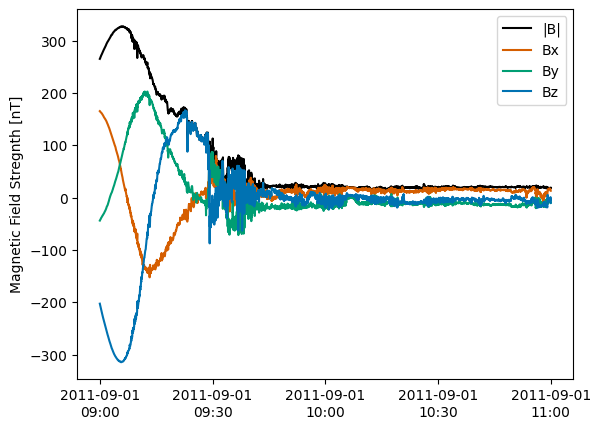

In [34]:
# Lets visualise this time range
fig, ax = plt.subplots()

to_plot = ["|B|", "Bx", "By", "Bz"]
colours = [hermpy.plotting.wong_colours[c] for c in ["black", "red", "green", "blue"]]

for var, colour in zip(to_plot, colours):
    ax.plot(data["date"], data[var], color=colour, label=var)

ax.legend()
ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator([0, 30]))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.set_ylabel("Magnetic Field Stregnth [nT]");

This crossing list is just a CSV file with times and labels:

In [35]:
crossing_list = pd.read_csv("./data/tmp/crossing_list.csv")
crossing_list["Time"] = pd.to_datetime(crossing_list["Time"])
crossing_list.head()

,Time,Label
0,2011-03-23 23:48:29.700,BS_IN
1,2011-03-23 23:58:05.200,BS_OUT
2,2011-03-23 23:59:46.200,BS_IN
3,2011-03-24 00:13:29.700,BS_OUT
4,2011-03-24 00:22:34.200,BS_IN


In [36]:
# We can filter this to just include crossings within our time range
crossing_list = crossing_list.loc[(crossing_list["Time"] > start_time) & (crossing_list["Time"] < end_time)]

The simplest way to view them would just be to plot as lines:

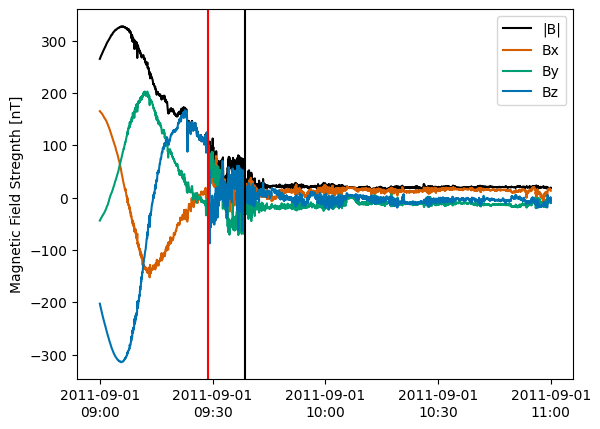

In [37]:
fig, ax = plt.subplots()

### The same code as above ###
to_plot = ["|B|", "Bx", "By", "Bz"]
colours = [hermpy.plotting.wong_colours[c] for c in ["black", "red", "green", "blue"]]

for var, colour in zip(to_plot, colours):
    ax.plot(data["date"], data[var], color=colour, label=var)

ax.legend()
ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator([0, 30]))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.set_ylabel("Magnetic Field Stregnth [nT]");
###############################

for _, crossing in crossing_list.iterrows():
  is_bow_shock = "BS" in crossing["Label"]
  ax.axvline(crossing["Time"], color="black" if is_bow_shock else "red")